# Phase 6 — Itinerary Analysis & Geographic Validation
## Travel Destination Recommendation System

This notebook provides experimentation, inspection, and analysis of the **Itinerary Generation Module** in the travel recommendation system. It calls the production implementation from `src/itinerary.py` and evaluation metrics from `src/itinerary_evaluation.py` to analyze geographic candidate selection, day clustering, travel pace capacities, and nearest-neighbor sequencing. It is a downstream extension that analyzes feasibility without modifying the underlying recommender logic.

### 1. Imports and Project Setup
We import standard packages, append the project directory to Python's system path, and import components from `src` to run our itinerary experiments.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Add project root directory to sys.path to import src
PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))

from src.preprocessing import load_dataset, prepare_attractions, prepare_interactions, train_test_split_by_user
from src.content_based import build_content_column, build_tfidf_matrix, recommend_attractions
from src.itinerary import (
    load_coordinates,
    haversine_distance,
    attach_coordinates,
    select_geographic_candidates,
    assign_days,
    enforce_day_capacity,
    order_day,
    build_itinerary
)
from src.itinerary_evaluation import evaluate_itinerary

### 2. Load Recommendation Candidates
We load the raw datasets and run Content-Based Filtering (CBF) to generate a representative Top-15 recommendation list for target user `149` in the training split. This Top-15 list serves as the candidate pool for itinerary generation.

In [2]:
csv_path = PROJECT_DIR / "data" / "tourism_recommendation_dataset_en.csv"
coords_path = PROJECT_DIR / "data" / "coordinates.csv"

dataset = load_dataset(str(csv_path))
coordinates_df = load_coordinates(str(coords_path))

attraction_df = prepare_attractions(dataset)
interactions_df = prepare_interactions(dataset)
train_df, test_df = train_test_split_by_user(interactions_df, test_ratio=0.2, min_interactions=5, random_state=42)

# CBF setup
content_df = build_content_column(attraction_df)
vectorizer, tfidf_matrix, attraction_index = build_tfidf_matrix(content_df)

# Generate candidates
sample_user_id = 149
candidates_df = recommend_attractions(
    tourist_id=sample_user_id,
    interactions_df=train_df,
    attraction_df=attraction_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    top_n=15
)

print(f"Generated {len(candidates_df)} recommendation candidates for tourist_id={sample_user_id}:")
display(candidates_df.head(5))

Generated 15 recommendation candidates for tourist_id=149:


,attraction_uid,attraction_name,attraction_category,city,similarity_score,rank
0,"Yan Dang Shan (Wen Zhou Shi, Zhejiang)",Yan Dang Shan,Natural Scenery,Wen Zhou Shi,0.602852,1
1,"Qian Shan (An Shan Shi, Liaoning)",Qian Shan,Natural Scenery,An Shan Shi,0.602768,2
2,"Shou Xi Hu (Yang Zhou Shi, Jiangsu)",Shou Xi Hu,Natural Scenery,Yang Zhou Shi,0.600272,3
3,"Hang Zhou Xi Xi Shi Di (Hang Zhou Shi, Zhejiang)",Hang Zhou Xi Xi Shi Di,Natural Scenery,Hang Zhou Shi,0.596542,4
4,"Tian Mu Hu (Chang Zhou Shi, Jiangsu)",Tian Mu Hu,Natural Scenery,Chang Zhou Shi,0.595075,5


### 3. Coordinate Attachment & Proximity Inspection
We attach geodetic coordinates to the candidates and compute their distance (in km) from the highest-ranked (Rank 1) anchor destination.

In [3]:
joined_df = attach_coordinates(candidates_df, coordinates_df)
print(f"Coordinate matched candidates: {len(joined_df)} / {len(candidates_df)}")

# Distance from Rank 1 anchor attraction
anchor = joined_df[joined_df["rank"] == 1].iloc[0]
anchor_lat, anchor_lon = anchor["latitude"], anchor["longitude"]

joined_df["dist_to_anchor_km"] = joined_df.apply(
    lambda r: haversine_distance(anchor_lat, anchor_lon, float(r["latitude"]), float(r["longitude"])),
    axis=1
)

print(f"\nAnchor Attraction (Rank 1): {anchor['attraction_name']} ({anchor['city']})")
display(joined_df[["rank", "attraction_name", "city", "dist_to_anchor_km"]].sort_values("rank"))

Coordinate matched candidates: 15 / 15

Anchor Attraction (Rank 1): Yan Dang Shan (Wen Zhou Shi)


,rank,attraction_name,city,dist_to_anchor_km
0,1,Yan Dang Shan,Wen Zhou Shi,0.000000
1,2,Qian Shan,An Shan Shi,1417.731225
2,3,Shou Xi Hu,Yang Zhou Shi,474.643435
3,4,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,228.320537
4,5,Tian Mu Hu,Chang Zhou Shi,360.107026
5,6,Huang Shan,Huang Shan Shi,338.285279
6,7,Qu Zhou Jiang Lang Shan,Qu Zhou Shi,219.776587
7,8,Tian Tang Zhai,Lu An Shi,588.616556
8,9,Mo Gan Shan,Hu Zhou Shi,271.537679
9,10,Bai Yun Shan,Luo Yang Shi,1052.896568


### 4. Geographic Candidate Selection Analysis
We run `select_geographic_candidates()` to identify which destinations are geographically compatible with the anchor's region and city, and which ones are distant outliers that must be excluded from the itinerary.

In [4]:
selected_df, geo_excluded_df = select_geographic_candidates(joined_df)
print(f"Geographically selected: {len(selected_df)} candidates")
print(f"Geographically excluded: {len(geo_excluded_df)} candidates")

# Create decisions summary table
selected_uids = set(selected_df["attraction_uid"])
decision_rows = []
for _, row in joined_df.iterrows():
    uid = row["attraction_uid"]
    is_sel = uid in selected_uids
    reason = "Selected" if is_sel else "Geographically Incompatible"
    decision_rows.append({
        "Rank": row["rank"],
        "Attraction": row["attraction_name"],
        "City": row["city"],
        "Distance (km)": f"{row['dist_to_anchor_km']:.2f}",
        "Selected?": "Yes" if is_sel else "No",
        "Decision Reason": reason
    })
display(pd.DataFrame(decision_rows))

Geographically selected: 8 candidates
Geographically excluded: 7 candidates


,Rank,Attraction,City,Distance (km),Selected?,Decision Reason
0,1,Yan Dang Shan,Wen Zhou Shi,0.00,Yes,Selected
1,2,Qian Shan,An Shan Shi,1417.73,No,Geographically Incompatible
2,3,Shou Xi Hu,Yang Zhou Shi,474.64,No,Geographically Incompatible
3,4,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,228.32,Yes,Selected
4,5,Tian Mu Hu,Chang Zhou Shi,360.11,Yes,Selected
5,6,Huang Shan,Huang Shan Shi,338.29,Yes,Selected
6,7,Qu Zhou Jiang Lang Shan,Qu Zhou Shi,219.78,Yes,Selected
7,8,Tian Tang Zhai,Lu An Shi,588.62,No,Geographically Incompatible
8,9,Mo Gan Shan,Hu Zhou Shi,271.54,Yes,Selected
9,10,Bai Yun Shan,Luo Yang Shi,1052.90,No,Geographically Incompatible


### 5. Travel-Day Experiments
We test generating itineraries with 1, 2, 3, and 4 travel days using the same input candidate pool under the `Balanced` pace setting.

In [5]:
day_exp_results = []
day_cases = [1, 2, 3, 4]

for days in day_cases:
    itinerary, excluded = build_itinerary(
        recommendations_df=candidates_df,
        coordinates_df=coordinates_df,
        num_days=days,
        travel_pace="Balanced",
        return_excluded=True
)
    
    # Calculate stop counts per day
    counts = [len(itinerary[itinerary["day"] == d]) for d in range(1, days + 1)]
    
    # Calculate total travel distances per day
    distances = [itinerary[itinerary["day"] == d]["distance_from_prev_km"].sum() for d in range(1, days + 1)]
    
    day_exp_results.append({
        "Requested Days": days,
        "Selected Stops": len(itinerary),
        "Excluded Count": len(excluded),
        "Daily Stop Counts": str(counts),
        "Daily Distances (km)": ", ".join([f"Day {i+1}: {d:.2f}" for i, d in enumerate(distances)])
    })

display(pd.DataFrame(day_exp_results))

Top-N candidates: 15
Geographically selected: 3
Excluded from itinerary: 12
Requested travel days: 1
Final itinerary attractions: 3
Day 1:
- attractions: ['Yan Dang Shan', 'Hang Zhou Xi Xi Shi Di', 'Tian Mu Hu']
- cities: ['Wen Zhou Shi', 'Hang Zhou Shi', 'Chang Zhou Shi']
- total Haversine distance: 360.16 km
K-Means cluster sizes: [3]
Top-N candidates: 15
Geographically selected: 6
Excluded from itinerary: 11
Requested travel days: 2
Final itinerary attractions: 4
Day 1:
- attractions: ['Yan Dang Shan']
- cities: ['Wen Zhou Shi']
- total Haversine distance: 0.00 km
Day 2:
- attractions: ['Hang Zhou Xi Xi Shi Di', 'Tian Mu Hu', 'Huang Shan']
- cities: ['Hang Zhou Shi', 'Chang Zhou Shi', 'Huang Shan Shi']
- total Haversine distance: 312.20 km
K-Means cluster sizes: [1, 3]
Top-N candidates: 15
Geographically selected: 8
Excluded from itinerary: 8
Requested travel days: 3
Final itinerary attractions: 7
Day 1:
- attractions: ['Yan Dang Shan', 'Wen Zhou Nan Xi Jiang']
- cities: ['Wen Zhou 

,Requested Days,Selected Stops,Excluded Count,Daily Stop Counts,Daily Distances (km)
0,1,3,12,[3],Day 1: 360.16
1,2,4,11,"[1, 3]","Day 1: 0.00, Day 2: 312.20"
2,3,7,8,"[2, 3, 2]","Day 1: 27.97, Day 2: 131.85, Day 3: 147.19"
3,4,8,7,"[2, 2, 2, 2]","Day 1: 27.97, Day 2: 43.26, Day 3: 76.57, Day ..."


### 6. Travel Pace Capacity Experiments
We evaluate how changing the travel pace (`Relaxed`, `Balanced`, `Packed`) affects the 3-day itinerary size, stop distribution, and overall travel distance.

In [6]:
pace_cases = ["Relaxed", "Balanced", "Packed"]
pace_results = []

for pace in pace_cases:
    itinerary, excluded = build_itinerary(
        recommendations_df=candidates_df,
        coordinates_df=coordinates_df,
        num_days=3,
        travel_pace=pace,
        return_excluded=True
    )
    
    counts = [len(itinerary[itinerary["day"] == d]) for d in range(1, 4)]
    empty_days = sum(1 for c in counts if c == 0)
    total_dist = itinerary["distance_from_prev_km"].sum()
    avg_consec = itinerary[itinerary["stop_order"] > 1]["distance_from_prev_km"].mean()
    
    pace_results.append({
        "Pace Setting": pace,
        "Selected Stops": len(itinerary),
        "Excluded Count": len(excluded),
        "Daily Counts": str(counts),
        "Max Stops/Day": max(counts) if counts else 0,
        "Empty Days count": empty_days,
        "Total Distance (km)": f"{total_dist:.2f}",
        "Avg Consecutive Distance (km)": f"{avg_consec:.2f}" if not pd.isna(avg_consec) else "0.00"
    })

display(pd.DataFrame(pace_results))

Top-N candidates: 15
Geographically selected: 6
Excluded from itinerary: 10
Requested travel days: 3
Final itinerary attractions: 5
Day 1:
- attractions: ['Yan Dang Shan']
- cities: ['Wen Zhou Shi']
- total Haversine distance: 0.00 km
Day 2:
- attractions: ['Hang Zhou Xi Xi Shi Di', 'Tian Mu Hu']
- cities: ['Hang Zhou Shi', 'Chang Zhou Shi']
- total Haversine distance: 131.84 km
Day 3:
- attractions: ['Huang Shan', 'Qu Zhou Jiang Lang Shan']
- cities: ['Huang Shan Shi', 'Qu Zhou Shi']
- total Haversine distance: 147.19 km
K-Means cluster sizes: [1, 2, 2]
Top-N candidates: 15
Geographically selected: 8
Excluded from itinerary: 8
Requested travel days: 3
Final itinerary attractions: 7
Day 1:
- attractions: ['Yan Dang Shan', 'Wen Zhou Nan Xi Jiang']
- cities: ['Wen Zhou Shi', 'Wen Zhou Shi']
- total Haversine distance: 27.97 km
Day 2:
- attractions: ['Hang Zhou Xi Xi Shi Di', 'Mo Gan Shan', 'Tian Mu Hu']
- cities: ['Hang Zhou Shi', 'Hu Zhou Shi', 'Chang Zhou Shi']
- total Haversine distan

,Pace Setting,Selected Stops,Excluded Count,Daily Counts,Max Stops/Day,Empty Days count,Total Distance (km),Avg Consecutive Distance (km)
0,Relaxed,5,10,"[1, 2, 2]",2,0,279.03,139.51
1,Balanced,7,8,"[2, 3, 2]",3,0,307.01,76.75
2,Packed,7,8,"[2, 3, 2]",3,0,307.01,76.75


### 7. Day Grouping Analysis (K-Means)
We inspect the daily assignments generated by K-Means on the geographically selected subset for a 3-day Balanced trip. We verify whether the assignments represent geographically coherent groups.

In [7]:
itinerary_3d = build_itinerary(
    recommendations_df=candidates_df,
    coordinates_df=coordinates_df,
    num_days=3,
    travel_pace="Balanced"
)

for day in range(1, 4):
    day_df = itinerary_3d[itinerary_3d["day"] == day].sort_values("stop_order")
    print(f"\n--- Day {day} Stops ---")
    if day_df.empty:
        print("No stops assigned to this day.")
    else: 
        display(day_df[["stop_order", "attraction_name", "city", "latitude", "longitude"]])

Top-N candidates: 15
Geographically selected: 8
Excluded from itinerary: 8
Requested travel days: 3
Final itinerary attractions: 7
Day 1:
- attractions: ['Yan Dang Shan', 'Wen Zhou Nan Xi Jiang']
- cities: ['Wen Zhou Shi', 'Wen Zhou Shi']
- total Haversine distance: 27.97 km
Day 2:
- attractions: ['Hang Zhou Xi Xi Shi Di', 'Mo Gan Shan', 'Tian Mu Hu']
- cities: ['Hang Zhou Shi', 'Hu Zhou Shi', 'Chang Zhou Shi']
- total Haversine distance: 131.85 km
Day 3:
- attractions: ['Huang Shan', 'Qu Zhou Jiang Lang Shan']
- cities: ['Huang Shan Shi', 'Qu Zhou Shi']
- total Haversine distance: 147.19 km
K-Means cluster sizes: [2, 3, 2]

--- Day 1 Stops ---


,stop_order,attraction_name,city,latitude,longitude
0,1,Yan Dang Shan,Wen Zhou Shi,28.39358,121.027942
1,2,Wen Zhou Nan Xi Jiang,Wen Zhou Shi,28.23810,120.803300



--- Day 2 Stops ---


,stop_order,attraction_name,city,latitude,longitude
2,1,Hang Zhou Xi Xi Shi Di,Hang Zhou Shi,30.266200,120.061700
3,2,Mo Gan Shan,Hu Zhou Shi,30.611700,119.854200
4,3,Tian Mu Hu,Chang Zhou Shi,31.325497,119.441588



--- Day 3 Stops ---


,stop_order,attraction_name,city,latitude,longitude
5,1,Huang Shan,Huang Shan Shi,30.1310,118.1650
6,2,Qu Zhou Jiang Lang Shan,Qu Zhou Shi,28.9574,118.8687


### 8. Within-Day Route Ordering
We inspect the sequencing generated by the Greedy Nearest-Neighbor heuristic using the Haversine distance formula, starting from the highest-ranked candidate of each day's cluster.

In [8]:
day1_df = itinerary_3d[itinerary_3d["day"] == 1].sort_values("stop_order")
print("Day 1 Route Sequence:")
for _, row in day1_df.iterrows():
    order = int(row["stop_order"])
    name = row["attraction_name"]
    dist = float(row["distance_from_prev_km"])
    if order == 1:
        print(f"Start → {name} (Highest-ranked anchor for Day 1)")
    else:
        print(f"      ↓ {dist:.2f} km")
        print(f"Stop {order} → {name}")

Day 1 Route Sequence:
Start → Yan Dang Shan (Highest-ranked anchor for Day 1)
      ↓ 27.97 km
Stop 2 → Wen Zhou Nan Xi Jiang


### 9. Excluded Recommendations Inspection
We analyze the `excluded_df` from our 3-day Balanced itinerary to understand why certain candidates were rejected.

In [9]:
_, excluded_df = build_itinerary(
    recommendations_df=candidates_df,
    coordinates_df=coordinates_df,
    num_days=3,
    travel_pace="Balanced",
    return_excluded=True
)

print(f"Total Excluded Candidates: {len(excluded_df)}")
print("\nExclusion Reason counts:")
display(excluded_df["exclusion_reason_label"].value_counts().to_frame())

print("\nExcluded Candidates Details:")
display(excluded_df[["attraction_name", "city", "rank", "exclusion_reason_label"]].sort_values("rank"))

Top-N candidates: 15
Geographically selected: 8
Excluded from itinerary: 8
Requested travel days: 3
Final itinerary attractions: 7
Day 1:
- attractions: ['Yan Dang Shan', 'Wen Zhou Nan Xi Jiang']
- cities: ['Wen Zhou Shi', 'Wen Zhou Shi']
- total Haversine distance: 27.97 km
Day 2:
- attractions: ['Hang Zhou Xi Xi Shi Di', 'Mo Gan Shan', 'Tian Mu Hu']
- cities: ['Hang Zhou Shi', 'Hu Zhou Shi', 'Chang Zhou Shi']
- total Haversine distance: 131.85 km
Day 3:
- attractions: ['Huang Shan', 'Qu Zhou Jiang Lang Shan']
- cities: ['Huang Shan Shi', 'Qu Zhou Shi']
- total Haversine distance: 147.19 km
K-Means cluster sizes: [2, 3, 2]
Total Excluded Candidates: 8

Exclusion Reason counts:


,count
exclusion_reason_label,
Too far from your top destination region,7
Exceeded daily capacity for this trip,1



Excluded Candidates Details:


,attraction_name,city,rank,exclusion_reason_label
0,Qian Shan,An Shan Shi,2,Too far from your top destination region
1,Shou Xi Hu,Yang Zhou Shi,3,Too far from your top destination region
2,Tian Tang Zhai,Lu An Shi,8,Too far from your top destination region
3,Bai Yun Shan,Luo Yang Shi,10,Too far from your top destination region
7,Yuan Tou Zhu,Wu Xi Shi,11,Exceeded daily capacity for this trip
4,Lao Shan,Qing Dao Shi,12,Too far from your top destination region
5,Tian Xia Di Yi Quan,Ji Nan Shi,13,Too far from your top destination region
6,Bai Shan Chang Bai Shan Da Xia Gu,Bai Shan Shi,14,Too far from your top destination region


### 10. Itinerary Evaluation
We call `evaluate_itinerary()` to run the five structural and geographic quality metrics implemented in `src/itinerary_evaluation.py`.

In [10]:
metrics = evaluate_itinerary(itinerary_3d, candidates_df)

print("Itinerary Quality Evaluation Metrics:")
for metric, val in metrics.items():
    print(f"\n* {metric}:")
    if isinstance(val, dict):
        for k, v in val.items():
            print(f"  - {k}: {v}")
    else:
        print(f"  - {val}")

Itinerary Quality Evaluation Metrics:

* avg_consecutive_distance:
  - day_1: 27.972552036849212
  - day_2: 65.92379005232202
  - day_3: 147.18534071987673
  - overall: 76.7513682153425

* total_distance_per_day:
  - day_1: 27.972552036849212
  - day_2: 131.84758010464404
  - day_3: 147.18534071987673
  - overall: 307.00547286137

* compactness_per_day:
  - day_1: 13.986278905543603
  - day_2: 48.99307216158041
  - day_3: 73.59293945614047
  - overall: 46.01966474401563

* candidate_carryover_rate:
  - 0.4666666666666667

* day_balance:
  - per_day_counts: {'day_1': 2, 'day_2': 3, 'day_3': 2}
  - std_dev: 0.4714045207910317
  - min_stops: 2
  - max_stops: 3


### 11. Visualizations
We plot a scatter plot of candidates' geographic coordinates to show the selected/excluded decision boundary and a bar chart showing stops count per day.

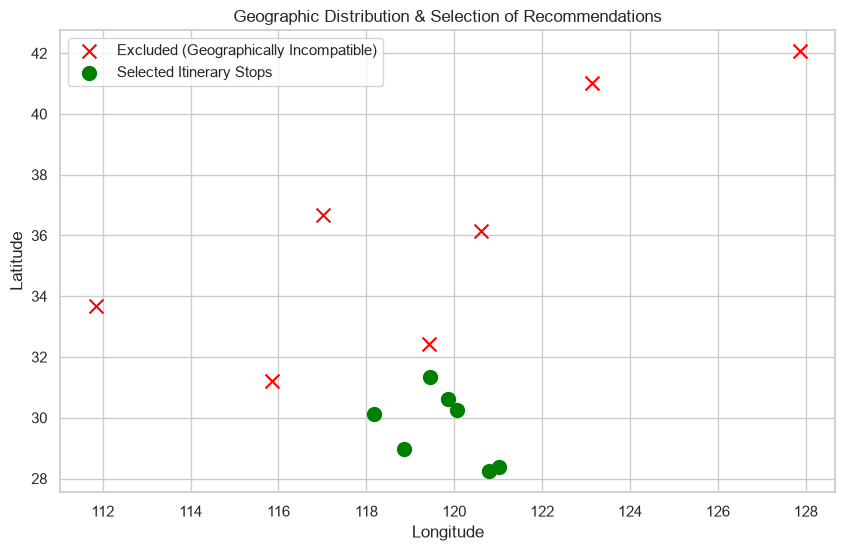

/var/folders/hs/vnv38zzd4rgcfjbxsnspr3f80000gn/T/ipykernel_23226/1809964361.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_labels, y=day_counts, palette="crest")


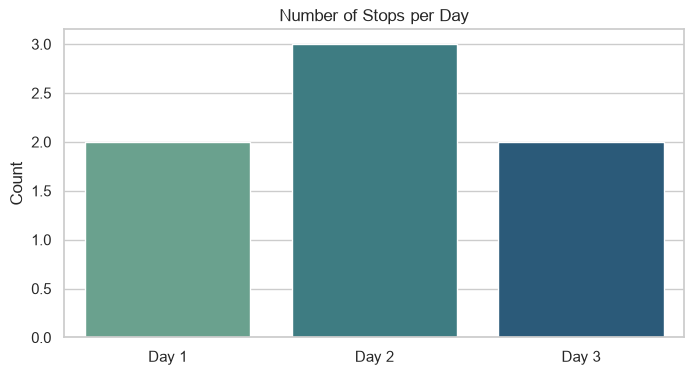

In [11]:
# Plot A: Scatter plot of candidates
plt.figure(figsize=(10, 6))

# Excluded
excluded_coords = joined_df[joined_df["attraction_uid"].isin(geo_excluded_df["attraction_uid"])]
ex_lats = excluded_coords["latitude"].tolist()
ex_lons = excluded_coords["longitude"].tolist()
plt.scatter(ex_lons, ex_lats, color="red", label="Excluded (Geographically Incompatible)", s=100, marker="x")

# Selected
sel_lats = itinerary_3d["latitude"].tolist()
sel_lons = itinerary_3d["longitude"].tolist()
plt.scatter(sel_lons, sel_lats, color="green", label="Selected Itinerary Stops", s=100, marker="o")

plt.title("Geographic Distribution & Selection of Recommendations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

# Plot B: Stops per day
plt.figure(figsize=(8, 4))
day_labels = [f"Day {d}" for d in range(1, 4)]
day_counts = [len(itinerary_3d[itinerary_3d["day"] == d]) for d in range(1, 4)]
sns.barplot(x=day_labels, y=day_counts, palette="crest")
plt.title("Number of Stops per Day")
plt.ylabel("Count")
plt.show()

### 12. Representative Scenarios

#### Scenario A — One-Day Trip
We compare the stop counts generated for a single-day trip under Relaxed, Balanced, and Packed paces.

In [12]:
print("Scenario A: 1-Day Trip Stop Count Comparison")
for pace in ["Relaxed", "Balanced", "Packed"]:
    it = build_itinerary(candidates_df, coordinates_df, num_days=1, travel_pace=pace)
    print(f"- Pace: {pace} -> Selected Stops: {len(it)}")

Scenario A: 1-Day Trip Stop Count Comparison
Top-N candidates: 15
Geographically selected: 2
Excluded from itinerary: 13
Requested travel days: 1
Final itinerary attractions: 2
Day 1:
- attractions: ['Yan Dang Shan', 'Hang Zhou Xi Xi Shi Di']
- cities: ['Wen Zhou Shi', 'Hang Zhou Shi']
- total Haversine distance: 228.32 km
K-Means cluster sizes: [2]
- Pace: Relaxed -> Selected Stops: 2
Top-N candidates: 15
Geographically selected: 3
Excluded from itinerary: 12
Requested travel days: 1
Final itinerary attractions: 3
Day 1:
- attractions: ['Yan Dang Shan', 'Hang Zhou Xi Xi Shi Di', 'Tian Mu Hu']
- cities: ['Wen Zhou Shi', 'Hang Zhou Shi', 'Chang Zhou Shi']
- total Haversine distance: 360.16 km
K-Means cluster sizes: [3]
- Pace: Balanced -> Selected Stops: 3
Top-N candidates: 15
Geographically selected: 3
Excluded from itinerary: 12
Requested travel days: 1
Final itinerary attractions: 3
Day 1:
- attractions: ['Yan Dang Shan', 'Hang Zhou Xi Xi Shi Di', 'Tian Mu Hu']
- cities: ['Wen Zhou S

#### Scenario C — Geographically Scattered Input Recommendations
We construct a mock candidate list with scattered locations (Shanghai, Beijing, Sichuan, Guangzhou) and run the itinerary generation module to inspect selection behavior.

In [13]:
scatter_data = [
    {"attraction_name": "Zhu Jia Jiao Gu Zhen", "city": "Shanghai", "province": "Shanghai", "rating": 5.0, "similarity_score": 0.95},
    {"attraction_name": "Bei Jing Zhi Wu Yuan", "city": "Beijing", "province": "Beijing", "rating": 4.8, "similarity_score": 0.90},
    {"attraction_name": "San Xing Dui Yi Zhi", "city": "De Yang Shi", "province": "Sichuan", "rating": 4.7, "similarity_score": 0.88},
    {"attraction_name": "Lu Shan", "city": "Jiu Jiang Shi", "province": "Jiangxi", "rating": 4.6, "similarity_score": 0.85},
    {"attraction_name": "Zhou Zhuang Gu Zhen", "city": "Su Zhou Shi", "province": "Jiangsu", "rating": 4.5, "similarity_score": 0.82},
    {"attraction_name": "Kai Feng Fu", "city": "Kai Feng Shi", "province": "Henan", "rating": 4.4, "similarity_score": 0.80}
]
scatter_df = pd.DataFrame(scatter_data)
scatter_df["attraction_uid"] = [
    f"{row['attraction_name']} ({row['city']}, {row['province']})" for row in scatter_data
]
scatter_df["rank"] = range(1, len(scatter_df) + 1)

it, ex = build_itinerary(
    recommendations_df=scatter_df,
    coordinates_df=coordinates_df,
    num_days=2,
    travel_pace="Balanced",
    return_excluded=True
)

print("Final Itinerary Stops (Selected):")
display(it[["day", "stop_order", "attraction_name", "city"]])

print("\nExcluded Outlier Attractions:")
display(ex[["attraction_name", "city", "exclusion_reason_label"]])

Top-N candidates: 6
Geographically selected: 3
Excluded from itinerary: 3
Requested travel days: 2
Final itinerary attractions: 3
Day 1:
- attractions: ['Zhu Jia Jiao Gu Zhen', 'Zhou Zhuang Gu Zhen']
- cities: ['Shanghai', 'Su Zhou Shi']
- total Haversine distance: 19.32 km
Day 2:
- attractions: ['Lu Shan']
- cities: ['Jiu Jiang Shi']
- total Haversine distance: 0.00 km
K-Means cluster sizes: [2, 1]
Final Itinerary Stops (Selected):


,day,stop_order,attraction_name,city
0,1,1,Zhu Jia Jiao Gu Zhen,Shanghai
1,1,2,Zhou Zhuang Gu Zhen,Su Zhou Shi
2,2,1,Lu Shan,Jiu Jiang Shi



Excluded Outlier Attractions:


,attraction_name,city,exclusion_reason_label
0,Bei Jing Zhi Wu Yuan,Beijing,Too far from your top destination region
1,San Xing Dui Yi Zhi,De Yang Shi,Too far from your top destination region
2,Kai Feng Fu,Kai Feng Shi,Too far from your top destination region


### 13. Implementation Observations & Interpretation
* **Geographic Coherence**: Outliers in distant provinces are filtered out by geographic anchor checks, keeping routes constrained to a single region.
* **Pace Controls**: Total stop capacities and per-day caps are strictly enforced, ensuring daily schedules match the selected travel pace (e.g. 2 stops max for Relaxed, 3 for Balanced/Packed).
* **Routing Optimality**: Stops are sequenced within days using a greedy nearest-neighbor heuristic based on the Haversine formula, starting from the highest-ranked spot in the day. This provides a spatial sequence but does not guarantee global optimality (e.g. TSP solution).
* **Thesis Metrics**: The metrics in `src/itinerary_evaluation.py` successfully characterize descriptive route qualities like consecutive distances and compactness.